# So sánh AOD AERONET vs Himawari (Petrenko/Ichoku collocation)

**Tiêu chí collocation (Wei 2019c / Petrenko-Ichoku):**

| Tham số | Giá trị | Lý do |
|---|---|---|
| Spatial radius | **±25 km** quanh trạm AERONET | Res Himawari L2 ARP ≈ 5 km (5×5 = 25 px window đã trích sẵn) |
| Temporal window | **±5 phút** quanh thời điểm vệ tinh | Himawari có ảnh mỗi 10 phút |
| Bước sóng | **500 nm** | AERONET 500 nm; Himawari AOT @ 500 nm |
| Min satellite pixels | **≥ 2** | `AOT_valid_count` |
| Min AERONET obs | **≥ 2** | Tránh đo lỗi |
| CoV satellite | **< 0.5** | `AOT_std / AOT_mean` |

**Nguồn Himawari:** `/home/slow_data/Air_Quality/Himawari/sites_aod_v3/L2/{station}.csv`
— file đã trích sẵn 5×5 = 25 pixel quanh mỗi trạm, kèm `AOT_mean`, `AOT_std`, `AOT_valid_count`.

In [ ]:
from datetime import timedelta
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import RANSACRegressor, LinearRegression

HIM_ROOT = Path('/home/slow_data/Air_Quality/Himawari/sites_aod_v4/L2')
AER_ROOT = Path('/home/slow_data/Air_Quality/AERONET/process/aod_500/10')

STATIONS = ['NGHIA_DO', 'Bac_Lieu']

DT_MIN  = 5     # ±5 phút
MIN_SAT = 2     # AOT_valid_count (5x5)
MIN_INNER = 2   # AOT_inner_count (3x3)
MIN_AER = 1
MAX_COV = 0.5

WINDOWS = [('5x5', 'sat_mean_5x5'), ('3x3', 'sat_mean_3x3')]

## 1. AERONET — lọc AOD 500 nm

In [ ]:
def load_aeronet(station):
    df = pd.read_csv(AER_ROOT / f'{station}.csv', low_memory=False)
    df['datetime'] = pd.to_datetime(df['datetime'])
    df = df[['datetime', 'aod_500', 'ae',]].rename(columns={
        'aod_500': 'aod500'
        })
    df = df[df['aod500'].between(0, 5)]
    return df.sort_values('datetime').reset_index(drop=True)

aer = {s: load_aeronet(s) for s in STATIONS}
for s, df in aer.items():
    print(f'{s}: {len(df):,} obs, {df.datetime.min()} -> {df.datetime.max()}')
aer['NGHIA_DO'].head(3)

NGHIA_DO: 13,279 obs, 2022-02-23 13:56:22 -> 2026-05-01 06:36:44
Bac_Lieu: 15,696 obs, 2022-04-21 06:38:46 -> 2025-08-22 10:16:10


,datetime,aod500,ae
0,2022-02-23 13:56:22,0.668412,1.316554
1,2022-02-23 14:01:22,0.680850,1.307935
2,2022-02-23 14:06:22,0.681717,1.292318


## 2. Himawari — đọc thẳng file đã pre-aggregate

Cột dùng:
- `AOT_mean` (5x5), `AOT_std`, `AOT_valid_count` → trung bình toàn cửa sổ 25 pixel
- `AOT_inner_mean` (3x3), `AOT_inner_count` → trung bình lõi 9 pixel
- Lọc Wei2019c áp dụng trên 5x5: `AOT_valid_count ≥ 2`, `CoV = AOT_std / AOT_mean < 0.5`
- 3x3 thêm điều kiện `AOT_inner_count ≥ 2`

In [ ]:
HIM_COLS = ['timestamp', 'AOT_mean', 'AOT_std', 'AOT_valid_count',
            'AOT_inner_mean', 'AOT_inner_count',
            'AOT_center']

def load_himawari(station):
    df = pd.read_csv(HIM_ROOT / f'{station}.csv', usecols=HIM_COLS, low_memory=False)
    df['ts'] = pd.to_datetime(df['timestamp'])
    df = df.dropna(subset=['AOT_mean'])
    df = df[df['AOT_mean'].between(0, 5)]
    return df.sort_values('ts').reset_index(drop=True)

him = {s: load_himawari(s) for s in STATIONS}
for s, df in him.items():
    print(f'{s}: {len(df):,} scenes, {df.ts.min()} -> {df.ts.max()}')
him['NGHIA_DO'].head(3)

NGHIA_DO: 6,774 scenes, 2022-10-05 07:20:00 -> 2026-06-04 16:50:00
Bac_Lieu: 7,239 scenes, 2022-10-16 07:10:00 -> 2026-06-05 08:00:00


,timestamp,AOT_valid_count,AOT_mean,AOT_std,AOT_center,AOT_inner_count,AOT_inner_mean,ts
0,2022-10-05 07:20:00,2,0.3856,0.0322,NaN,0,NaN,2022-10-05 07:20:00
1,2022-10-05 15:50:00,1,0.3906,NaN,NaN,0,NaN,2022-10-05 15:50:00
2,2022-10-11 10:00:00,1,0.3960,NaN,NaN,1,0.396,2022-10-11 10:00:00


## 3. Collocation

Với mỗi scene Himawari hợp lệ (N≥2, CoV<0.5):
- Tìm các đo AERONET trong **±5 phút** quanh `ts`.
- Cần ≥ 2 đo AERONET → lấy mean.

In [ ]:
def collocate(station, df_aer, df_him):
    df_h = df_him.copy()
    df_h['cov'] = df_h['AOT_std'] / df_h['AOT_mean'].replace(0, np.nan)
    df_h = df_h[(df_h['AOT_valid_count'] >= MIN_SAT) & (df_h['cov'] < MAX_COV)]

    a_times = df_aer['datetime'].values.astype('datetime64[ns]')
    a_vals  = df_aer['aod500'].values
    dt_ns   = np.timedelta64(DT_MIN, 'm')

    rows = []
    for _, r in df_h.iterrows():
        ts = np.datetime64(r['ts'])
        mask = (a_times >= ts - dt_ns) & (a_times <= ts + dt_ns)
        if mask.sum() < MIN_AER:
            continue
        sub = a_vals[mask]
        inner_n = int(r['AOT_inner_count']) if pd.notna(r['AOT_inner_count']) else 0
        sat_3x3 = float(r['AOT_inner_mean']) if inner_n >= MIN_INNER else np.nan
        rows.append({
            'station':      station,
            'ts':           r['ts'],
            'aer_mean':     float(sub.mean()),
            'aer_std':      float(sub.std(ddof=0)),
            'aer_n':        int(mask.sum()),
            'sat_mean_5x5': float(r['AOT_mean']),
            'sat_mean_3x3': sat_3x3,
            'sat_std':      float(r['AOT_std']),
            'sat_cov':      float(r['cov']),
            'sat_n':        int(r['AOT_valid_count']),
            'sat_inner_n':  inner_n,
            'sat_ae':       r.get('AE', np.nan),
        })
    return pd.DataFrame(rows)

In [ ]:
pairs = pd.concat(
    [collocate(s, aer[s], him[s]) for s in STATIONS],
    ignore_index=True,
)
print(f'Total pairs: {len(pairs):,}')
print(f"  5x5 valid: {pairs['sat_mean_5x5'].notna().sum():,}")
print(f"  3x3 valid: {pairs['sat_mean_3x3'].notna().sum():,}")
print(pairs.groupby('station').size())
pairs.head()

Total pairs: 1,762
  5x5 valid: 1,762
  3x3 valid: 1,058
station
Bac_Lieu     153
NGHIA_DO    1609
dtype: int64


,station,ts,aer_mean,aer_std,aer_n,sat_mean_5x5,sat_mean_3x3,sat_std,sat_cov,sat_n,sat_inner_n,sat_ae
0,NGHIA_DO,2022-10-15 10:00:00,0.317211,0.005159,2,0.474771,0.510133,0.046803,0.098580,7,3,NaN
1,NGHIA_DO,2022-10-15 11:00:00,0.306594,0.003833,2,0.442800,NaN,0.109400,0.247064,2,0,NaN
2,NGHIA_DO,2022-10-16 10:10:00,0.294685,0.004994,2,0.411667,NaN,0.049121,0.119323,3,0,NaN
3,NGHIA_DO,2022-10-16 10:20:00,0.305268,0.012793,2,0.390800,NaN,0.011200,0.028659,2,0,NaN
4,NGHIA_DO,2022-10-16 14:40:00,0.427286,0.003720,2,0.555867,NaN,0.141253,0.254113,3,1,NaN


## 4. Metrics

- **R**: Pearson correlation
- **RMSE**, **MAE**, **MBE**
- **EE envelope**: tỉ lệ điểm trong `±(0.05 + 0.15·AOD_AERONET)`
- **OLS**: simple linear regression (`y = slope·x + intercept`)
- **RANSAC**: robust regression (loại outlier) → `slope_r`, `intercept_r`, `N_in` inliers

In [ ]:
def fit_ransac(x, y, seed=0):
    if len(x) < 3:
        return np.nan, np.nan, 0
    try:
        ransac = RANSACRegressor(
            estimator=LinearRegression(),
            min_samples=max(2, int(0.2 * len(x))),
            residual_threshold=None,  # MAD-based
            random_state=seed,
        ).fit(x.reshape(-1, 1), y)
        slope = float(ransac.estimator_.coef_[0])
        intercept = float(ransac.estimator_.intercept_)
        n_in = int(ransac.inlier_mask_.sum())
        return slope, intercept, n_in
    except ValueError:
        return np.nan, np.nan, 0

def evaluate(df, sat_col='sat_mean_5x5'):
    sub = df.dropna(subset=['aer_mean', sat_col])
    x = sub['aer_mean'].values
    y = sub[sat_col].values
    n = len(sub)
    if n < 2:
        return {'N': n, 'R': np.nan, 'RMSE': np.nan, 'MAE': np.nan,
                'MBE': np.nan, 'within_EE': np.nan,
                'slope': np.nan, 'intercept': np.nan,
                'slope_r': np.nan, 'intercept_r': np.nan, 'N_in': 0}
    r, _ = stats.pearsonr(x, y)
    rmse = float(np.sqrt(np.mean((y - x) ** 2)))
    mae  = float(np.mean(np.abs(y - x)))
    mbe  = float(np.mean(y - x))
    ee   = 0.05 + 0.15 * x
    within_ee = float(np.mean((y - x >= -ee) & (y - x <= ee)))
    slope, intercept = np.polyfit(x, y, 1)
    slope_r, intercept_r, n_in = fit_ransac(x, y)
    return {'N': n, 'R': r, 'RMSE': rmse, 'MAE': mae, 'MBE': mbe,
            'within_EE': within_ee,
            'slope': float(slope), 'intercept': float(intercept),
            'slope_r': slope_r, 'intercept_r': intercept_r, 'N_in': n_in}

summary = {}
for win_label, sat_col in WINDOWS:
    summary[f'ALL [{win_label}]'] = evaluate(pairs, sat_col)
    for s, grp in pairs.groupby('station'):
        summary[f'{s} [{win_label}]'] = evaluate(grp, sat_col)
pd.DataFrame(summary).T.round(3)

,N,R,RMSE,MAE,MBE,within_EE,slope,intercept,slope_r,intercept_r,N_in
ALL [5x5],1762.0,0.579,0.720,0.514,-0.225,0.287,0.251,0.653,0.298,0.553,952.0
Bac_Lieu [5x5],153.0,0.683,0.306,0.253,0.247,0.118,0.875,0.281,1.219,0.172,103.0
NGHIA_DO [5x5],1609.0,0.523,0.748,0.538,-0.270,0.303,0.219,0.712,0.196,0.761,736.0
ALL [3x3],1058.0,0.447,0.784,0.605,-0.221,0.233,0.163,0.885,0.108,0.988,395.0
Bac_Lieu [3x3],50.0,0.872,0.222,0.203,0.187,0.140,0.595,0.283,0.649,0.264,29.0
NGHIA_DO [3x3],1008.0,0.363,0.802,0.625,-0.241,0.237,0.119,0.969,0.089,1.041,433.0


## 5. Scatter + EE envelope

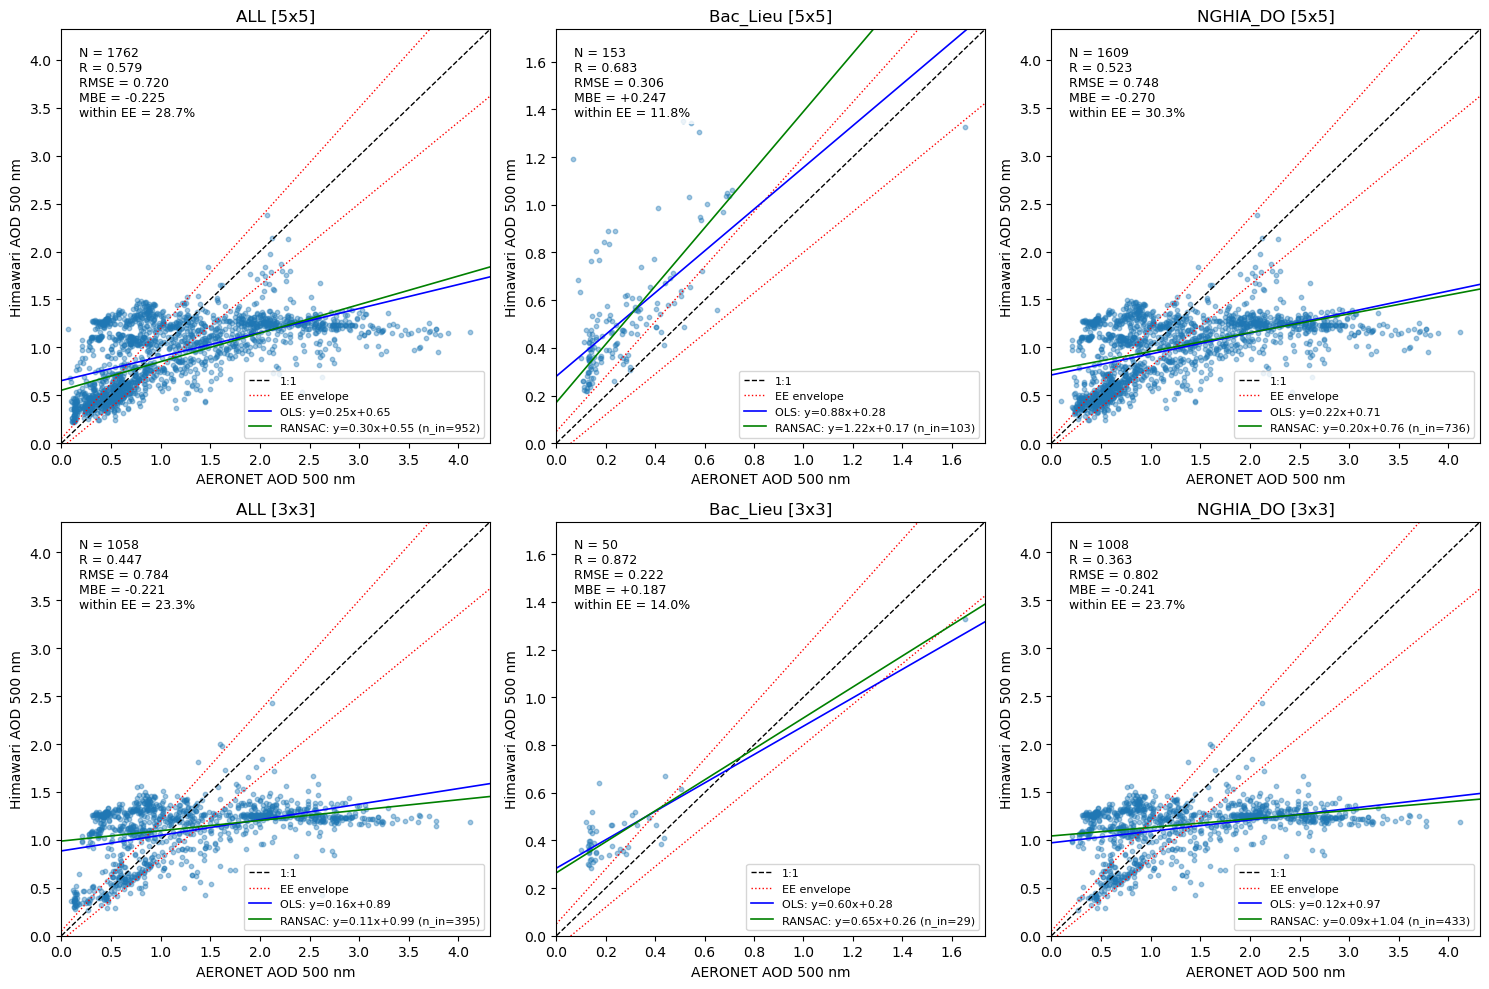

In [ ]:
def plot_scatter(ax, df, sat_col, label):
    sub = df.dropna(subset=['aer_mean', sat_col])
    if len(sub) == 0:
        ax.set_title(f'{label} - empty'); return
    x = sub['aer_mean'].values; y = sub[sat_col].values
    m = evaluate(sub, sat_col)
    ax.scatter(x, y, s=10, alpha=0.4)
    lim = max(x.max(), y.max()) * 1.05
    grid = np.linspace(0, lim, 100)
    ax.plot(grid, grid, 'k--', lw=1, label='1:1')
    ax.plot(grid, grid + (0.05 + 0.15 * grid), 'r:', lw=1, label='EE envelope')
    ax.plot(grid, grid - (0.05 + 0.15 * grid), 'r:', lw=1)
    if np.isfinite(m['slope']):
        ax.plot(grid, m['slope'] * grid + m['intercept'], 'b-', lw=1.2,
                label=f"OLS: y={m['slope']:.2f}x+{m['intercept']:.2f}")
    if np.isfinite(m['slope_r']):
        ax.plot(grid, m['slope_r'] * grid + m['intercept_r'], 'g-', lw=1.2,
                label=f"RANSAC: y={m['slope_r']:.2f}x+{m['intercept_r']:.2f} (n_in={m['N_in']})")
    txt = (f"N = {m['N']}\nR = {m['R']:.3f}\nRMSE = {m['RMSE']:.3f}\n"
           f"MBE = {m['MBE']:+.3f}\nwithin EE = {m['within_EE']*100:.1f}%")
    ax.text(0.04, 0.96, txt, transform=ax.transAxes, va='top', fontsize=9,
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
    ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    ax.set_xlabel('AERONET AOD 500 nm'); ax.set_ylabel('Himawari AOD 500 nm')
    ax.set_title(label); ax.legend(loc='lower right', fontsize=8)

groups = [('ALL', pairs)] + [(s, g) for s, g in pairs.groupby('station')]
fig, axes = plt.subplots(len(WINDOWS), len(groups),
                        figsize=(5 * len(groups), 5 * len(WINDOWS)),
                        squeeze=False)
for i, (win_label, sat_col) in enumerate(WINDOWS):
    for j, (g_label, df) in enumerate(groups):
        plot_scatter(axes[i, j], df, sat_col, f'{g_label} [{win_label}]')
fig.tight_layout(); plt.show()

## 6. Bias theo AOD bin và theo giờ UTC

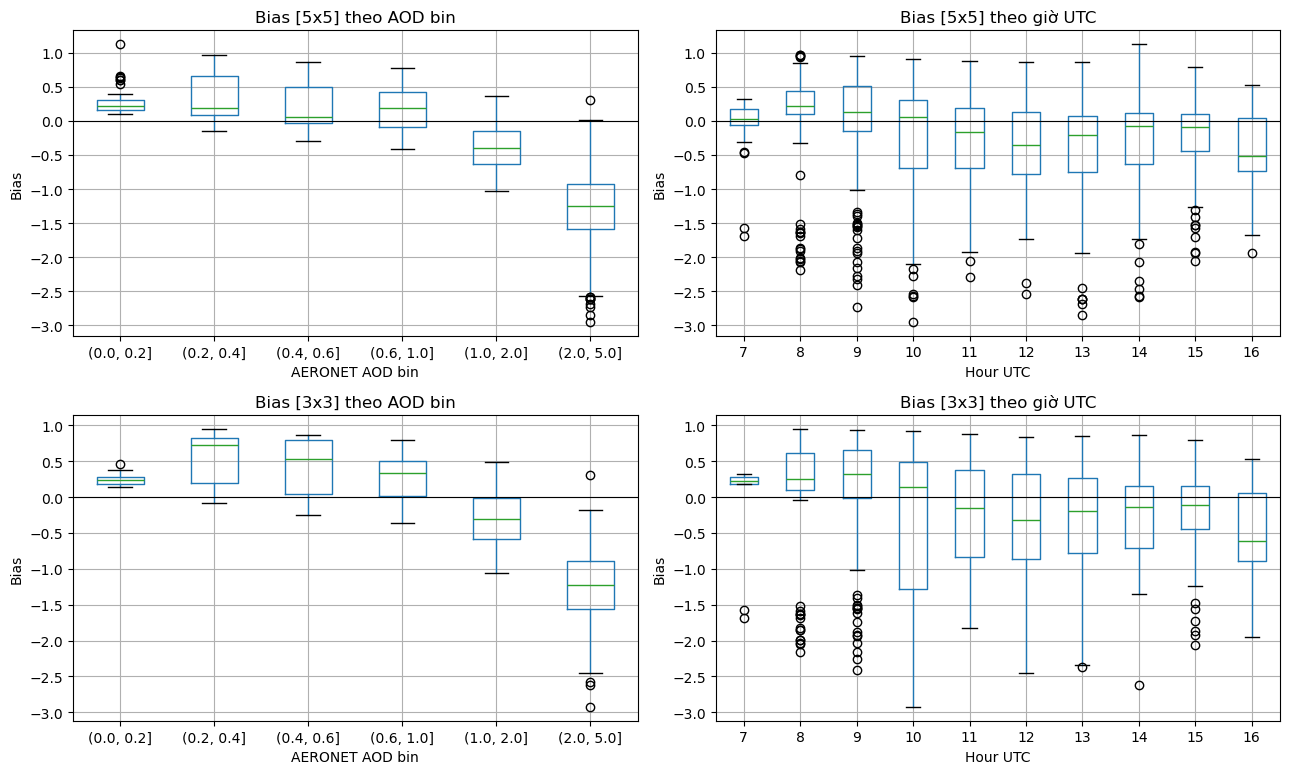

In [ ]:
if len(pairs):
    pairs['bias_5x5'] = pairs.sat_mean_5x5 - pairs.aer_mean
    pairs['bias_3x3'] = pairs.sat_mean_3x3 - pairs.aer_mean
    pairs['hour_utc'] = pd.to_datetime(pairs.ts).dt.hour
    pairs['aod_bin']  = pd.cut(pairs.aer_mean,
                               bins=[0, 0.2, 0.4, 0.6, 1.0, 2.0, 5.0])
    fig, axes = plt.subplots(len(WINDOWS), 2, figsize=(13, 4 * len(WINDOWS)),
                             squeeze=False)
    for i, (win_label, _) in enumerate(WINDOWS):
        bcol = f'bias_{win_label}'
        pairs.boxplot(column=bcol, by='aod_bin', ax=axes[i, 0])
        axes[i, 0].axhline(0, color='k', lw=0.8)
        axes[i, 0].set_title(f'Bias [{win_label}] theo AOD bin')
        axes[i, 0].set_xlabel('AERONET AOD bin'); axes[i, 0].set_ylabel('Bias')
        pairs.boxplot(column=bcol, by='hour_utc', ax=axes[i, 1])
        axes[i, 1].axhline(0, color='k', lw=0.8)
        axes[i, 1].set_title(f'Bias [{win_label}] theo giờ UTC')
        axes[i, 1].set_xlabel('Hour UTC'); axes[i, 1].set_ylabel('Bias')
    plt.suptitle(''); fig.tight_layout(); plt.show()

## 7. Density scatter theo giờ UTC

Mỗi panel là một giờ UTC. Mật độ điểm tô màu bằng Gaussian KDE — đỉnh đỏ/vàng = vùng tập trung, đuôi xanh = outlier. Hiển thị hour có ≥ `MIN_N_HOUR` cặp.

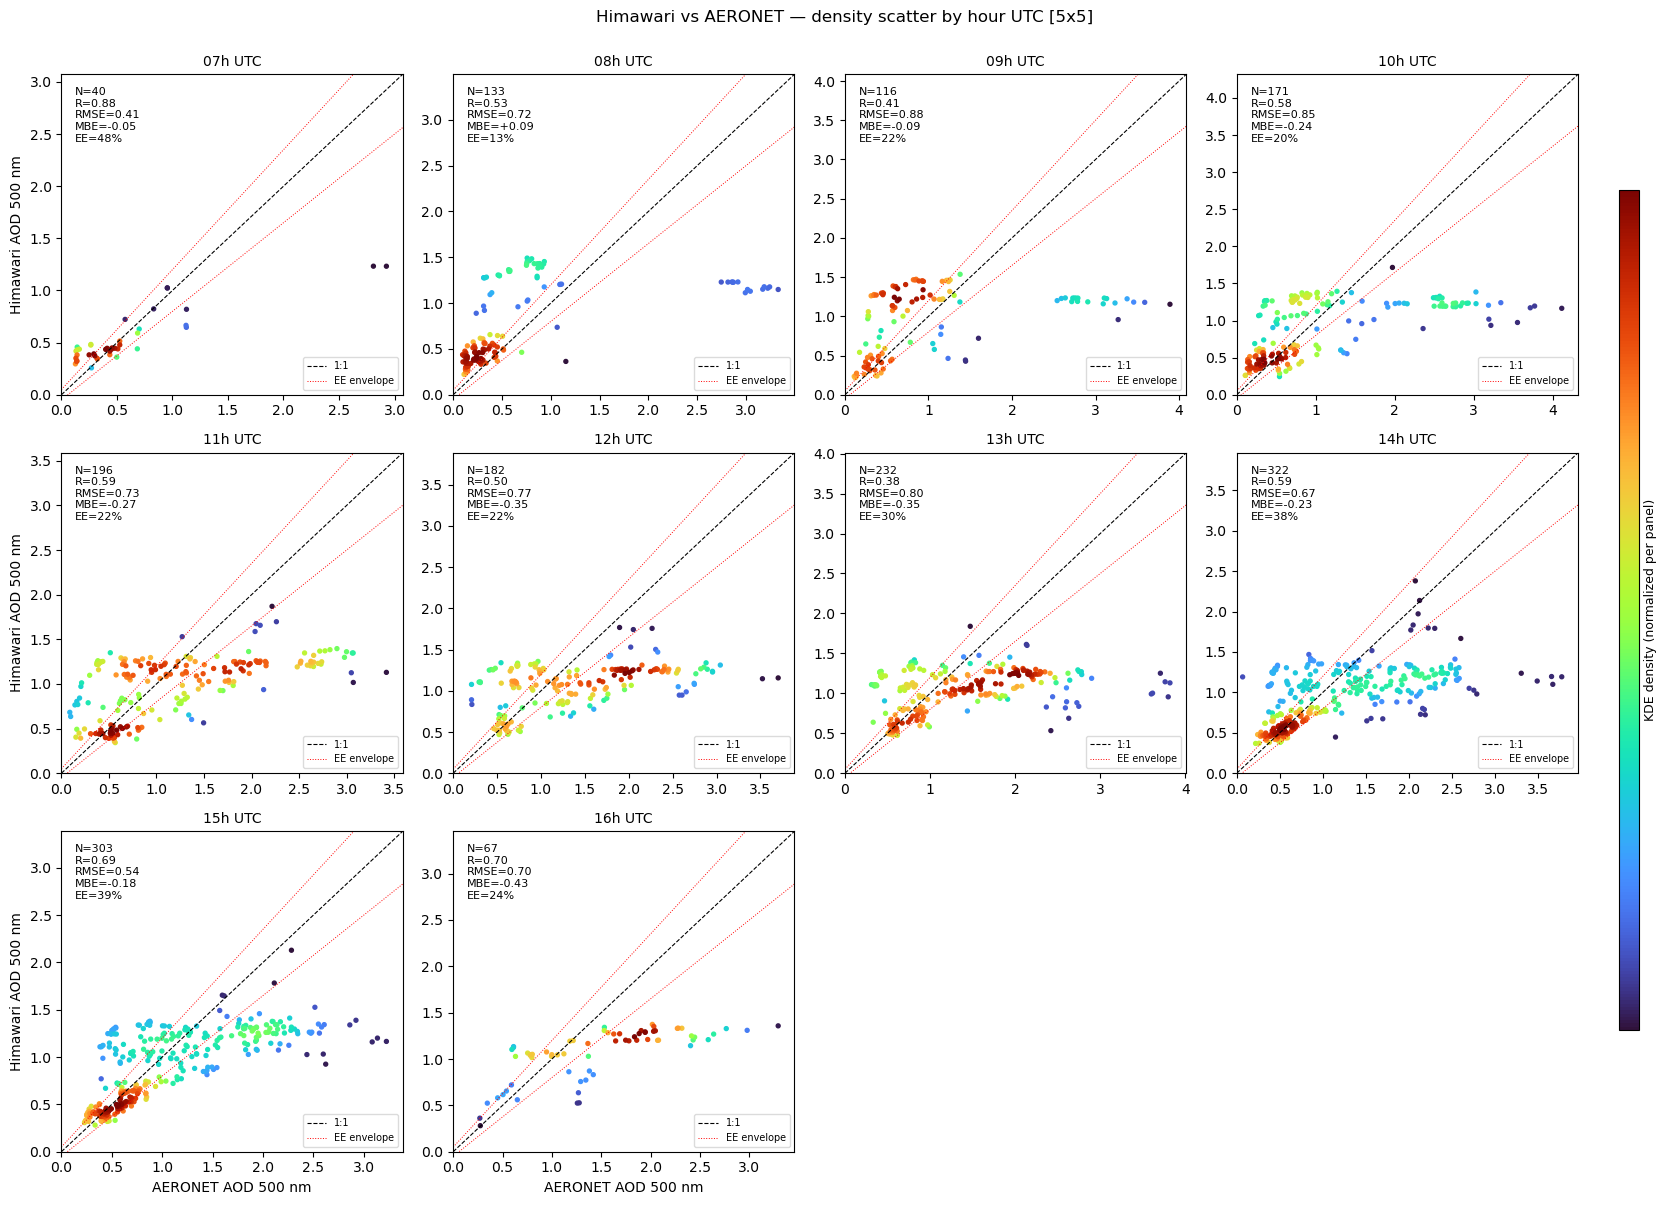

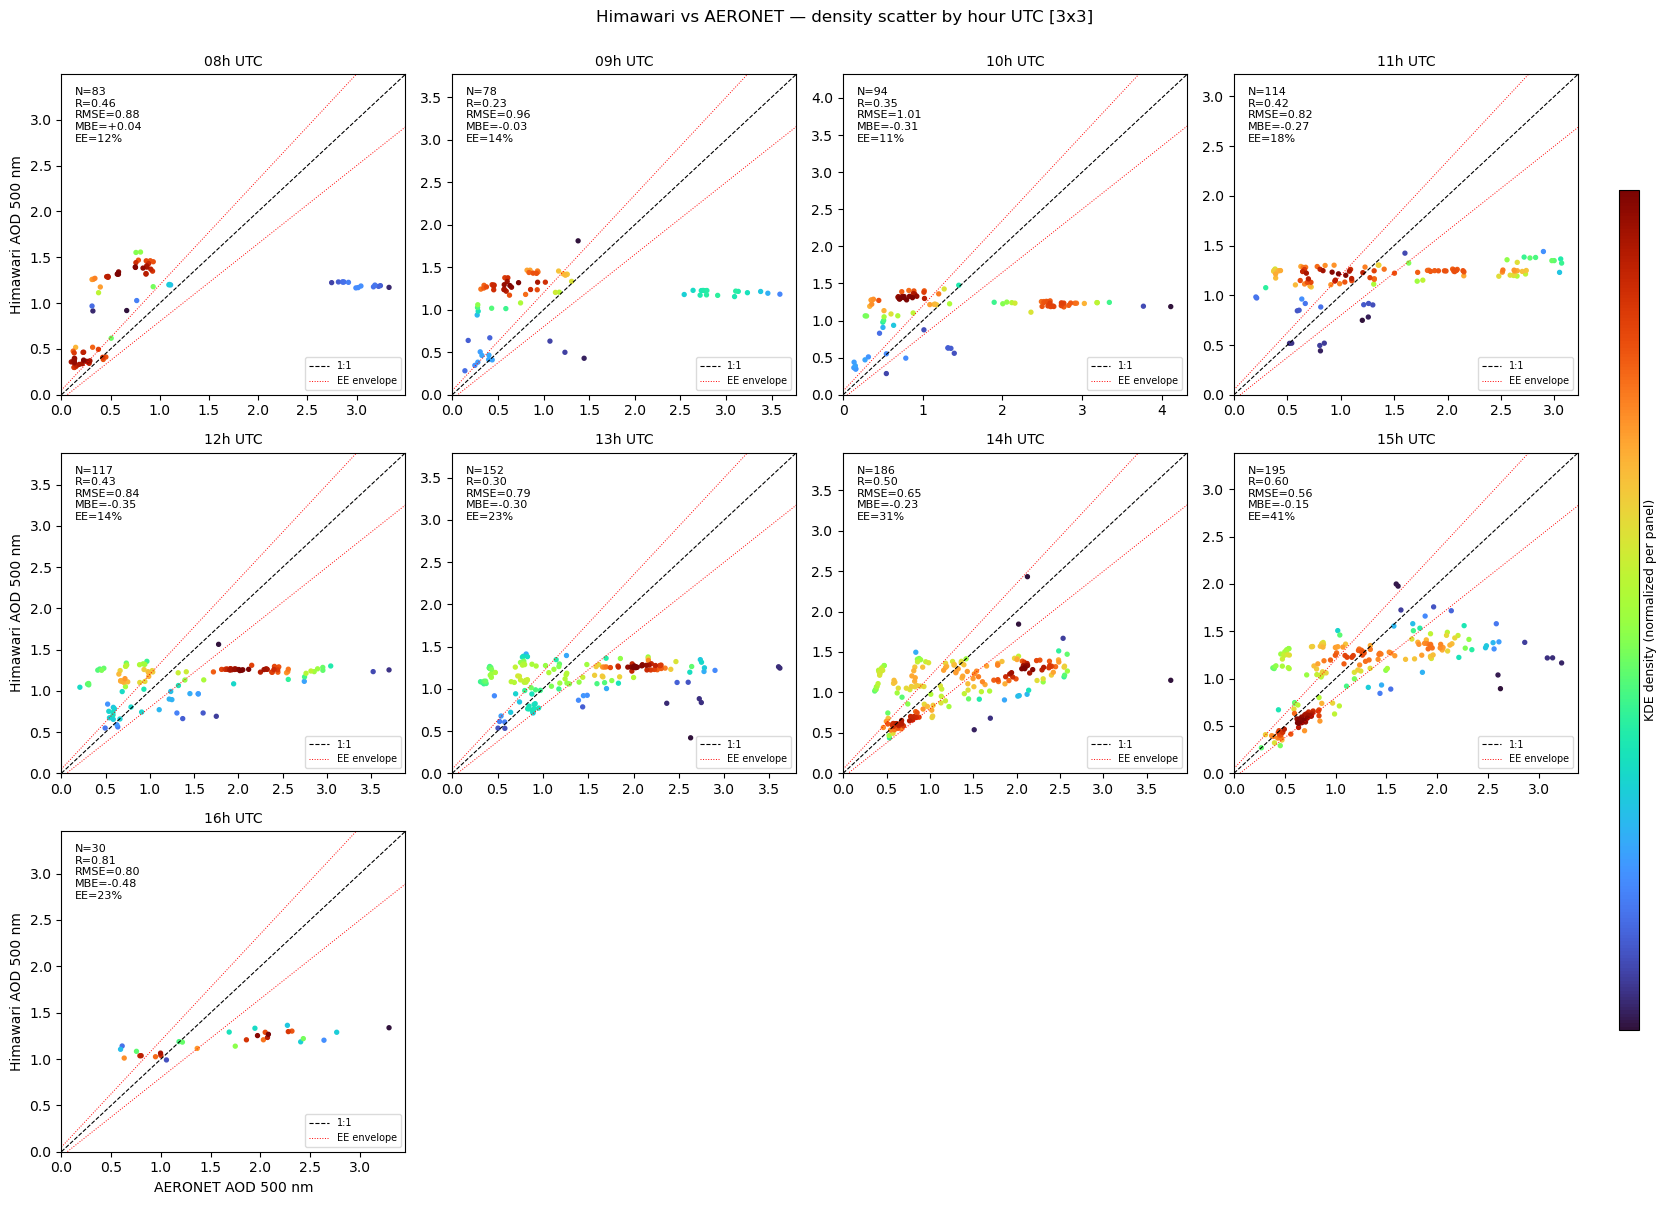

In [ ]:
MIN_N_HOUR = 10
NCOLS_HOUR = 4

def _density_panel(ax, x, y, label):
    n = len(x)
    sc = None
    if n == 0:
        ax.set_title(f'{label} - empty'); ax.set_axis_off(); return sc
    if n >= 5:
        try:
            xy = np.vstack([x, y])
            z = stats.gaussian_kde(xy)(xy)
            order = z.argsort()
            x, y, z = x[order], y[order], z[order]
            sc = ax.scatter(x, y, c=z, s=8, cmap='turbo')
        except Exception:
            ax.scatter(x, y, s=8, alpha=0.5)
    else:
        ax.scatter(x, y, s=8, alpha=0.5)
    lim = max(float(x.max()), float(y.max()), 0.1) * 1.05
    grid = np.linspace(0, lim, 100)
    l_11, = ax.plot(grid, grid, 'k--', lw=0.8, label='1:1')
    l_ee, = ax.plot(grid, grid + (0.05 + 0.15 * grid), 'r:', lw=0.7, label='EE envelope')
    ax.plot(grid, grid - (0.05 + 0.15 * grid), 'r:', lw=0.7)
    if n >= 2:
        r, _ = stats.pearsonr(x, y)
        rmse = float(np.sqrt(np.mean((y - x) ** 2)))
        mbe  = float(np.mean(y - x))
        ee   = 0.05 + 0.15 * x
        within = float(np.mean((y - x >= -ee) & (y - x <= ee)))
        txt = (f"N={n}\nR={r:.2f}\nRMSE={rmse:.2f}\n"
               f"MBE={mbe:+.2f}\nEE={within*100:.0f}%")
        ax.text(0.04, 0.96, txt, transform=ax.transAxes, va='top', fontsize=8,
                bbox=dict(facecolor='white', alpha=0.85, edgecolor='none'))
    ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    ax.set_title(label, fontsize=10)
    ax.legend(handles=[l_11, l_ee], loc='lower right', fontsize=7, framealpha=0.7)
    return sc

def density_scatter_by_hour(df, sat_col, sensor_label, win_label):
    sub = df.dropna(subset=['aer_mean', sat_col]).copy()
    sub['hour_utc'] = pd.to_datetime(sub.ts).dt.hour
    counts = sub.groupby('hour_utc').size()
    hours = sorted(counts[counts >= MIN_N_HOUR].index.tolist())
    if not hours:
        print(f'{sensor_label} [{win_label}]: no hour has >= {MIN_N_HOUR} pairs'); return
    nrows = int(np.ceil(len(hours) / NCOLS_HOUR))
    fig, axes = plt.subplots(nrows, NCOLS_HOUR,
                             figsize=(4 * NCOLS_HOUR + 1, 4 * nrows), squeeze=False)
    last_sc = None
    for i, h in enumerate(hours):
        ax = axes[i // NCOLS_HOUR, i % NCOLS_HOUR]
        g = sub[sub.hour_utc == h]
        sc = _density_panel(ax, g['aer_mean'].values, g[sat_col].values, f'{h:02d}h UTC')
        if sc is not None:
            last_sc = sc
        if i // NCOLS_HOUR == nrows - 1:
            ax.set_xlabel('AERONET AOD 500 nm')
        if i % NCOLS_HOUR == 0:
            ax.set_ylabel(f'{sensor_label} AOD 500 nm')
    for j in range(len(hours), nrows * NCOLS_HOUR):
        axes[j // NCOLS_HOUR, j % NCOLS_HOUR].set_axis_off()
    fig.suptitle(f'{sensor_label} vs AERONET — density scatter by hour UTC [{win_label}]',
                 y=1.0, fontsize=12)
    fig.tight_layout(rect=[0, 0, 0.94, 1.0])
    if last_sc is not None:
        cax = fig.add_axes([0.955, 0.15, 0.012, 0.7])
        cbar = fig.colorbar(last_sc, cax=cax)
        cbar.set_label('KDE density (normalized per panel)', fontsize=9)
        cbar.set_ticks([])
    plt.show()

for win_label, sat_col in WINDOWS:
    density_scatter_by_hour(pairs, sat_col, 'Himawari', win_label)